
RECOMMENDATION

Chiến lược tối ưu được mô hình đề xuất là:

• ATM: +20%
• Mobile: +40%
• Online: +25%
• Fee: +10%

Chiến lược này đạt Final Score cao nhất
(0.901),
giúp tối đa hóa đồng thời:

✓ Transaction Volume
✓ Channel Revenue
✓ Branch Performance



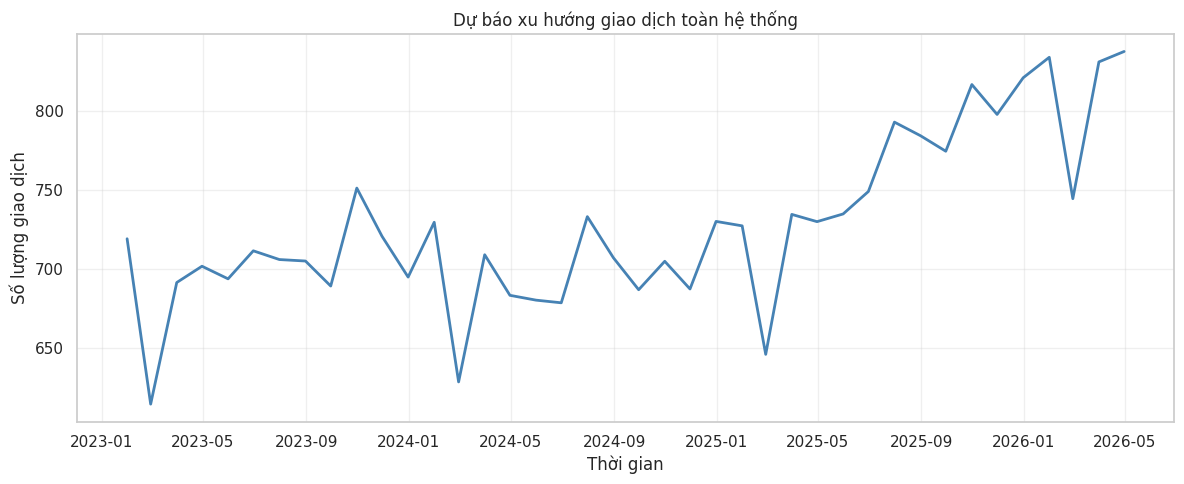

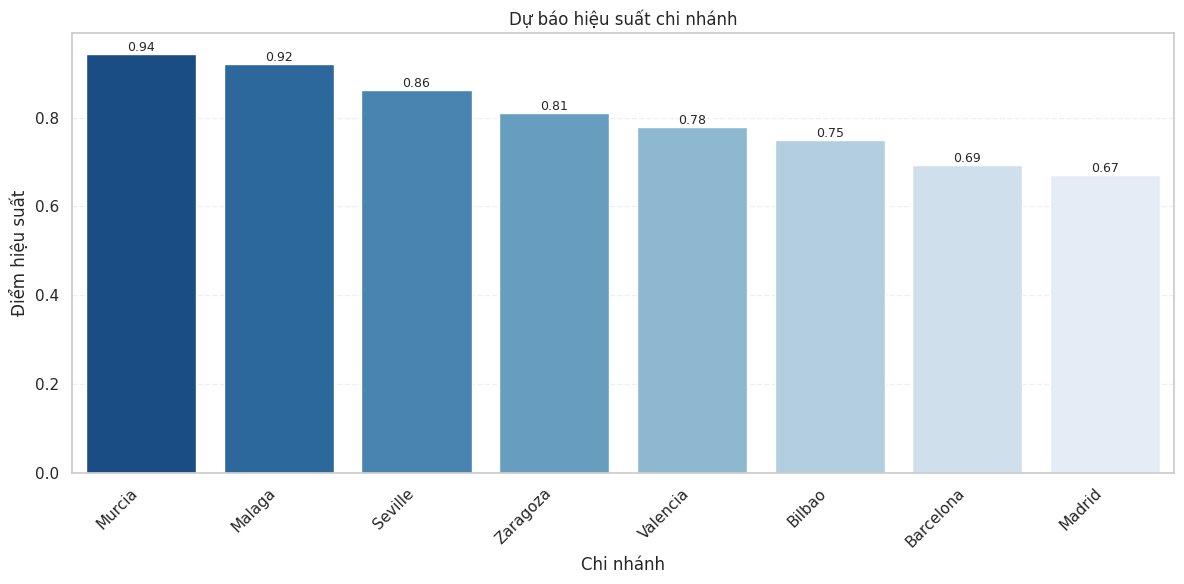

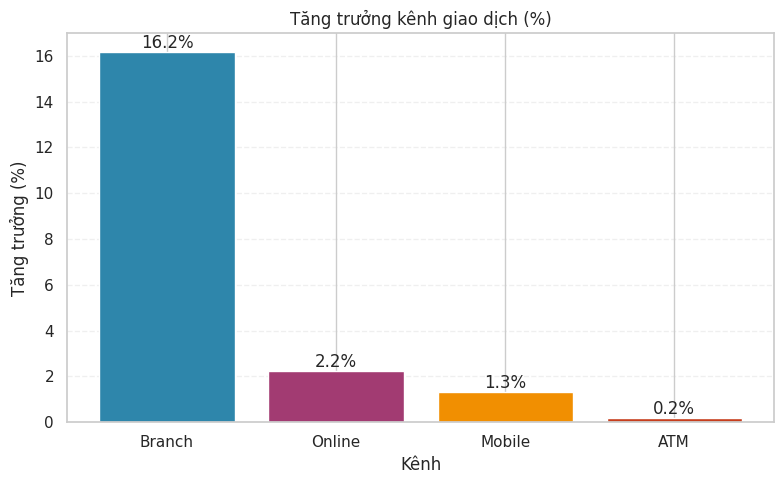


TOP 10 STRATEGIES
    ATM  Mobile  Online   Fee  VolumeNorm  RevenueNorm  BranchNorm  FinalScore
80  0.2     0.4    0.25  0.10    1.000000     1.000000    0.506315    0.901263
77  0.2     0.4    0.10  0.10    0.829719     0.896290    0.719780    0.834360
74  0.2     0.4    0.00  0.10    0.716199     0.827150    0.870048    0.791349
53  0.1     0.4    0.25  0.10    0.886146     0.929285    0.257908    0.777754
79  0.2     0.4    0.25  0.00    1.000000     0.685104    0.506315    0.775305
71  0.2     0.2    0.25  0.10    0.755755     0.851655    0.612701    0.765504
78  0.2     0.4    0.25 -0.05    1.000000     0.527657    0.506315    0.712326
76  0.2     0.4    0.10  0.00    0.829719     0.590822    0.719780    0.712173
50  0.1     0.4    0.10  0.10    0.715865     0.825575    0.467223    0.710020
68  0.2     0.2    0.10  0.10    0.585474     0.747945    0.839760    0.701319


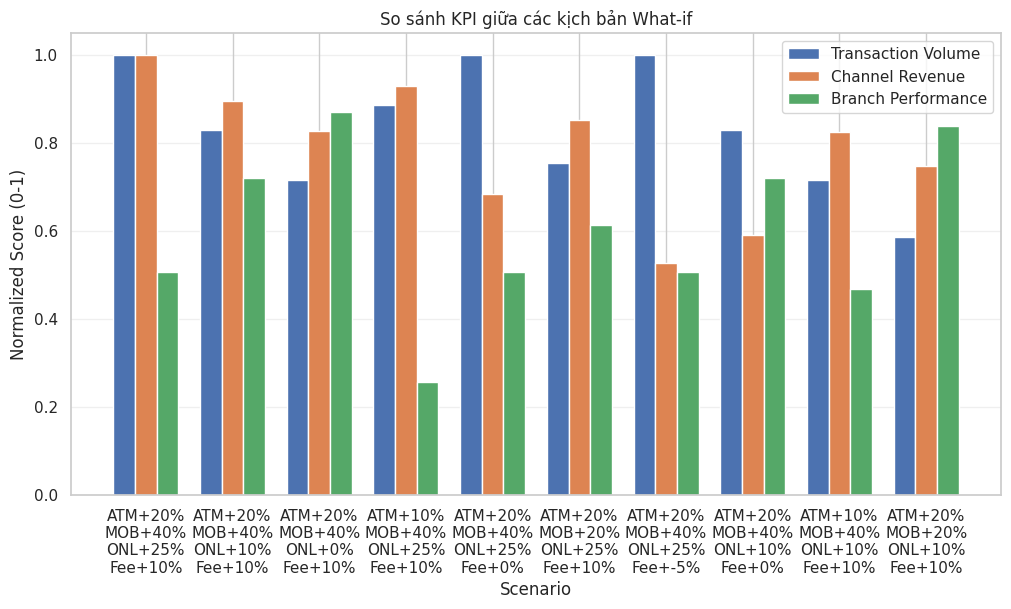

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
import logging

logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').disabled = True

sns.set(style="whitegrid")

# =========================
# 1. LOAD DATA
# =========================
file_path = '/content/Banking_Transactional_Dataset.xlsx'
df = pd.read_excel(file_path)

df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])

# =========================
# 2. REMOVE INCOMPLETE MONTH (05/2025)
# =========================
df = df[~(
    (df['TransactionDate'].dt.year == 2025) &
    (df['TransactionDate'].dt.month == 5)
)]

# =========================
# 3. FEATURE ENGINEERING
# =========================
df['FeeRevenue'] = df['Amount'] * 0.02
df['Year'] = df['TransactionDate'].dt.year
df['Month'] = df['TransactionDate'].dt.month

# =========================
# 4. GLOBAL FORECAST
# =========================
monthly_volume = df.groupby(
    pd.Grouper(key='TransactionDate', freq='ME')
).size().reset_index(name='Volume')

forecast_data = monthly_volume.rename(columns={'TransactionDate': 'ds', 'Volume': 'y'})

model_global = Prophet()
model_global.fit(forecast_data)

future_global = model_global.make_future_dataframe(periods=12, freq='ME')
forecast_global = model_global.predict(future_global)

# =========================
# 5. BRANCH PERFORMANCE SCORE (WITH FEE REVENUE)
# =========================
branch_monthly = df.groupby(
    ['BranchCity', pd.Grouper(key='TransactionDate', freq='ME')]
).agg({
    'TransactionID': 'count',
    'Amount': 'sum',
    'FeeRevenue': 'sum'
}).reset_index()

branch_monthly.columns = ['BranchCity', 'Date', 'Volume', 'Amount', 'FeeRevenue']

# Normalize
branch_monthly['VolumeNorm'] = branch_monthly['Volume'] / branch_monthly['Volume'].max()
branch_monthly['RevenueNorm'] = branch_monthly['Amount'] / branch_monthly['Amount'].max()
branch_monthly['FeeNorm'] = branch_monthly['FeeRevenue'] / branch_monthly['FeeRevenue'].max()

branch_monthly['BranchPerformance'] = (
    0.4 * branch_monthly['VolumeNorm'] +
    0.4 * branch_monthly['RevenueNorm'] +
    0.2 * branch_monthly['FeeNorm']
)

# =========================
# 6. BRANCH FORECAST
# =========================
cities = branch_monthly['BranchCity'].unique()

branch_result = []

for city in cities:

    data = branch_monthly[branch_monthly['BranchCity'] == city][['Date', 'BranchPerformance']]
    data = data.rename(columns={'Date': 'ds', 'BranchPerformance': 'y'}).dropna()

    model = Prophet()
    model.fit(data)

    future = model.make_future_dataframe(periods=12, freq='ME')
    forecast = model.predict(future)

    branch_result.append({
        'BranchCity': city,
        'ForecastPerformance': forecast['yhat'].iloc[-1]
    })

branch_result = pd.DataFrame(branch_result).sort_values('ForecastPerformance', ascending=False)

# =========================
# 7. CHANNEL FORECAST
# =========================
channel_monthly = df.groupby(
    ['Channel', pd.Grouper(key='TransactionDate', freq='ME')]
).size().reset_index(name='Volume')

channels = channel_monthly['Channel'].unique()

channel_result = []

for ch in channels:

    data = channel_monthly[channel_monthly['Channel'] == ch][['TransactionDate', 'Volume']]
    data = data.rename(columns={'TransactionDate': 'ds', 'Volume': 'y'})

    model = Prophet()
    model.fit(data)

    future = model.make_future_dataframe(periods=12, freq='ME')
    forecast = model.predict(future)

    current = data['y'].tail(12).mean()
    future_avg = forecast['yhat'].tail(12).mean()

    growth = 0 if current == 0 else (future_avg - current) / current * 100

    channel_result.append({
        'Channel': ch,
        'GrowthRate': growth,
        'ForecastVolume': future_avg
    })

channel_result = pd.DataFrame(channel_result).sort_values('GrowthRate', ascending=False)

# =====================================================
# 8. WHAT-IF ANALYSIS + SIMULATION ANALYTICS
# =====================================================

scenarios = []

atm_growth = [0, 0.1, 0.2]
mobile_growth = [0, 0.2, 0.4]
online_growth = [0, 0.1, 0.25]
fee_change = [-0.05, 0, 0.1]

base_volume = len(df)
base_revenue = df['FeeRevenue'].sum()

for atm in atm_growth:
    for mobile in mobile_growth:
        for online in online_growth:
            for fee in fee_change:

                temp = df.copy()

                # =========================
                # Transaction Volume
                # =========================

                temp['VolumeFactor'] = temp['Channel'].map({
                    'ATM': 1 + atm,
                    'Mobile': 1 + mobile,
                    'Online': 1 + online
                }).fillna(1)

                temp['SimVolume'] = temp['VolumeFactor']

                total_volume = temp['SimVolume'].sum()

                # =========================
                # Revenue
                # =========================

                temp['SimRevenue'] = (
                    temp['Amount']
                    * 0.02
                    * (1 + fee)
                    * temp['VolumeFactor']
                )

                total_revenue = temp['SimRevenue'].sum()

                # =========================
                # Branch Performance
                # =========================

                branch_perf = temp.groupby('BranchCity').agg({
                    'SimVolume': 'sum',
                    'SimRevenue': 'sum'
                }).reset_index()

                branch_perf['VolumeNorm'] = (
                    branch_perf['SimVolume']
                    / branch_perf['SimVolume'].max()
                )

                branch_perf['RevenueNorm'] = (
                    branch_perf['SimRevenue']
                    / branch_perf['SimRevenue'].max()
                )

                branch_perf['Score'] = (
                    0.6 * branch_perf['VolumeNorm']
                    + 0.4 * branch_perf['RevenueNorm']
                )

                avg_branch_score = branch_perf['Score'].mean()

                scenarios.append({
                    'ATM': atm,
                    'Mobile': mobile,
                    'Online': online,
                    'Fee': fee,
                    'TotalVolume': total_volume,
                    'TotalRevenue': total_revenue,
                    'BranchScore': avg_branch_score
                })

simulation_df = pd.DataFrame(scenarios)

# =====================================================
# KPI NORMALIZATION
# =====================================================

simulation_df['VolumeNorm'] = (
    simulation_df['TotalVolume']
    - simulation_df['TotalVolume'].min()
) / (
    simulation_df['TotalVolume'].max()
    - simulation_df['TotalVolume'].min()
)

simulation_df['RevenueNorm'] = (
    simulation_df['TotalRevenue']
    - simulation_df['TotalRevenue'].min()
) / (
    simulation_df['TotalRevenue'].max()
    - simulation_df['TotalRevenue'].min()
)

simulation_df['BranchNorm'] = (
    simulation_df['BranchScore']
    - simulation_df['BranchScore'].min()
) / (
    simulation_df['BranchScore'].max()
    - simulation_df['BranchScore'].min()
)

# =====================================================
# FINAL SCORE
# =====================================================

simulation_df['FinalScore'] = (
    0.4 * simulation_df['VolumeNorm']
    + 0.4 * simulation_df['RevenueNorm']
    + 0.2 * simulation_df['BranchNorm']
)

simulation_df = simulation_df.sort_values(
    'FinalScore',
    ascending=False
)
# =========================
# 10. PRESCRIPTIVE ANALYTICS
# =========================
best_strategy = simulation_df.iloc[0]

print("\nRECOMMENDATION")

print(
    f"""
Chiến lược tối ưu được mô hình đề xuất là:

• ATM: +{best_strategy['ATM']*100:.0f}%
• Mobile: +{best_strategy['Mobile']*100:.0f}%
• Online: +{best_strategy['Online']*100:.0f}%
• Fee: +{best_strategy['Fee']*100:.0f}%

Chiến lược này đạt Final Score cao nhất
({best_strategy['FinalScore']:.3f}),
giúp tối đa hóa đồng thời:

✓ Transaction Volume
✓ Channel Revenue
✓ Branch Performance
"""
)
# =========================
# 11. VISUALIZATION (CLEAR + BUSINESS STYLE)
# =========================

# Global forecast
plt.figure(figsize=(12,5))

plt.plot(
    forecast_global['ds'],
    forecast_global['yhat'],
    linewidth=2,
    color='steelblue'
)

plt.title("Dự báo xu hướng giao dịch toàn hệ thống")
plt.xlabel("Thời gian")
plt.ylabel("Số lượng giao dịch")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Branch performance
plt.figure(figsize=(12,6))

branch_sorted = branch_result.sort_values('ForecastPerformance', ascending=False)

ax = sns.barplot(
    data=branch_sorted,
    x='BranchCity',
    y='ForecastPerformance',
    hue='BranchCity',
    palette='Blues_r',
    legend=False
)

plt.title("Dự báo hiệu suất chi nhánh")
plt.xlabel("Chi nhánh")
plt.ylabel("Điểm hiệu suất")

plt.xticks(rotation=45, ha='right')

# label rõ hơn
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Channel growth
plt.figure(figsize=(8,5))

channel_sorted = channel_result.sort_values('GrowthRate', ascending=False)

bars = plt.bar(
    channel_sorted['Channel'],
    channel_sorted['GrowthRate'],
    color=['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
)

plt.title("Tăng trưởng kênh giao dịch (%)")
plt.xlabel("Kênh")
plt.ylabel("Tăng trưởng (%)")

plt.xticks(rotation=0)

for b in bars:
    plt.text(
        b.get_x() + b.get_width()/2,
        b.get_height(),
        f"{b.get_height():.1f}%",
        ha='center',
        va='bottom'
    )

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()
# Simulation
# ====================================
# TOP 10 SCENARIOS
# ====================================
print("\nTOP 10 STRATEGIES")

top = simulation_df.head(10).copy()

print(
    top[
        [
            'ATM',
            'Mobile',
            'Online',
            'Fee',
            'VolumeNorm',
            'RevenueNorm',
            'BranchNorm',
            'FinalScore'
        ]
    ]
)

top['Scenario'] = top.apply(
    lambda x:
    f"ATM+{int(x['ATM']*100)}%\n"
    f"MOB+{int(x['Mobile']*100)}%\n"
    f"ONL+{int(x['Online']*100)}%\n"
    f"Fee+{int(x['Fee']*100)}%",
    axis=1
)

plt.figure(figsize=(12,6))

x = np.arange(len(top))
w = 0.25

plt.bar(
    x-w,
    top['VolumeNorm'],
    width=w,
    label='Transaction Volume'
)

plt.bar(
    x,
    top['RevenueNorm'],
    width=w,
    label='Channel Revenue'
)

plt.bar(
    x+w,
    top['BranchNorm'],
    width=w,
    label='Branch Performance'
)

plt.xticks(x, top['Scenario'])

plt.ylabel('Normalized Score (0-1)')
plt.xlabel('Scenario')
plt.title('So sánh KPI giữa các kịch bản What-if')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

In [2]:
branch_result.to_csv(
    "branch_forecast.csv",
    index=False
)

channel_result.to_csv(
    "channel_forecast.csv",
    index=False
)

top.to_csv(
    "top10_strategy.csv",
    index=False
)

forecast_global[['ds','yhat']].to_csv(
    "transaction_forecast.csv",
    index=False
)

print("Export success")

Export success
